# Single-view lighting probe

For one fixed object and camera, only the illumination changes. The experiment asks whether that change is represented by RayDer, and whether it is represented more clearly after RayDer's nuisance projection than in either its full backbone token or a generic visual backbone.

Every rendered image is measured along the same three feature axes:

- **RayDer token (1024D):** the backbone camera token after the pose head's normalization and before its output projection.
- **RayDer nuisance (256D):** the dynamic-state projection of the same backbone token.
- **DINOv3 (1024D):** the pooled class token from the mirrored DINOv3 ViT-L/16, loaded through Transformers.

The comparison uses pairwise geometry and a held-out linear lighting probe. Masked linear-RGB distance controls for image appearance; DINOv3 controls for lighting information available to a generic pretrained visual representation.

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/rayder-matplotlib")

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from einops import reduce as einops_reduce, repeat
from scipy.spatial import HalfspaceIntersection
from scipy.spatial.transform import Rotation
from scipy.stats import rankdata, spearmanr
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from transformers import AutoImageProcessor, AutoModel

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "rayder").is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rayder.model import Camera, PLUECKER_DIM, RayDer_L, _prepare_temporal_ranks, make_axial_pos_3d
from rayder.open_illumination import OpenIlluminationOLAT

/mnt/warm/dev/rayder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experimental design

Let $w_i \in \Delta^5$ be mixture $i$ over six measured OLAT lights with unit directions $\ell_k \in \mathbb{S}^2$. Four symmetric Dirichlet distributions, $w_i \sim \operatorname{Dir}(\alpha \mathbf{1})$ for $\alpha \in \{0.25, 0.5, 1, 2\}$, cover sparse through diffuse lighting while preserving $\sum_k w_{ik}=1$. The effective first-order lighting direction is

$$e_i = \sum_{k=1}^{6} w_{ik}\ell_k.$$

It is used only to color plots. Opposing lights cancel near the origin, so $e_i$ is deliberately not normalized. The six lights are selected geometrically as the measured directions nearest $\{\pm x,\pm y,\pm z\}$; neither appearance nor model features affect the selection.

In [3]:
DATA_ROOT = REPO_ROOT / "notebooks/data/openillumination-mini"
OBJECT_ID, CAMERA, RESOLUTION = 5, "A1", 256
NUM_MIXTURES, SEED, EXPOSURE_EV = 500, 20260902, 3.0
RENDER_BATCH_SIZE, MASK, SUBTRACT_BACKGROUND = 8, None, False
IMAGE_DISTANCE_MASK = "object"
DINO_ID = "devvcamp07/dinov3-mirror"

dataset = OpenIlluminationOLAT(DATA_ROOT, OBJECT_ID, download_missing=False)
light_directions = torch.tensor(dataset.load_light_positions(normalize=True), dtype=torch.float32)
axis_labels = ("+x", "-x", "+y", "-y", "+z", "-z")
target_axes = torch.tensor([[1, 0, 0], [-1, 0, 0], [0, 1, 0], [0, -1, 0], [0, 0, 1], [0, 0, -1.0]])
light_indices = (light_directions @ target_axes.T).argmax(0)
assert light_indices.unique().numel() == 6
selected_directions = light_directions[light_indices]

torch.manual_seed(SEED)
concentrations = torch.tensor([0.25, 0.5, 1.0, 2.0])
counts = torch.full((len(concentrations),), NUM_MIXTURES // len(concentrations))
counts[: NUM_MIXTURES % len(concentrations)] += 1
mixture_weights = torch.cat([
    torch.distributions.Dirichlet(torch.full((6,), alpha)).sample((int(count),))
    for alpha, count in zip(concentrations, counts)
])
mixture_family = torch.repeat_interleave(concentrations, counts)
order = torch.randperm(NUM_MIXTURES)
mixture_weights, mixture_family = mixture_weights[order], mixture_family[order]
effective_lights = mixture_weights @ selected_directions
direction_colors = ((effective_lights + 1) / 2).clamp(0, 1)
assert torch.allclose(mixture_weights.sum(1), torch.ones(NUM_MIXTURES))

for label, index, direction in zip(axis_labels, light_indices, selected_directions):
    print(f"{label:>2}: light {index.item():3d}, direction={direction.tolist()}")

+x: light  82, direction=[0.9949327707290649, 0.012538393028080463, -0.09975770115852356]
-x: light  77, direction=[-0.9934996366500854, 0.055403318256139755, 0.09944342076778412]
+y: light 139, direction=[0.32102105021476746, 0.8998042941093445, 0.2954619228839874]
-y: light   0, direction=[0.002798927715048194, -0.987995445728302, 0.15445780754089355]
+z: light  62, direction=[-0.11902597546577454, 0.013896279968321323, 0.9927939176559448]
-z: light  86, direction=[0.13224151730537415, 0.05854164436459541, -0.9894872903823853]


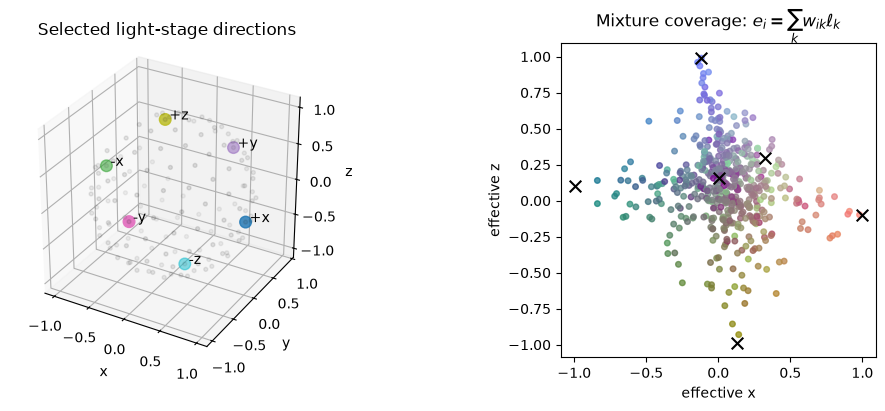

In [6]:
fig = plt.figure(figsize=(11, 4), constrained_layout=True)
ax = fig.add_subplot(121, projection="3d")
ax.scatter(*light_directions.T, s=8, alpha=0.35, color="0.1")
ax.scatter(*selected_directions.T, s=70, c=range(6), cmap="tab10")
for label, direction in zip(axis_labels, selected_directions):
    ax.text(*direction, f" {label}")
ax.set(title="Selected light-stage directions", xlabel="x", ylabel="y", zlabel="z")
ax.set_box_aspect((1, 1, 1))
ax = fig.add_subplot(122)
ax.scatter(*effective_lights[:, [0, 2]].T, c=direction_colors, s=16, alpha=0.75)
ax.scatter(*selected_directions[:, [0, 2]].T, c="black", marker="x", s=70)
ax.set(title=r"Mixture coverage: $e_i=\sum_k w_{ik}\ell_k$", xlabel="effective x", ylabel="effective z", aspect="equal")
plt.show()

## Inputs and exposure check

The six one-hot mixtures expose the individual OLAT basis images; the final image uses uniform illumination. Because every sampled image is a convex mixture of this basis, inspecting the basis also supplies a conservative clipping check for all mixtures. Rendering, RayDer, and DINOv3 consume the same cropped $256^2$ sRGB images.

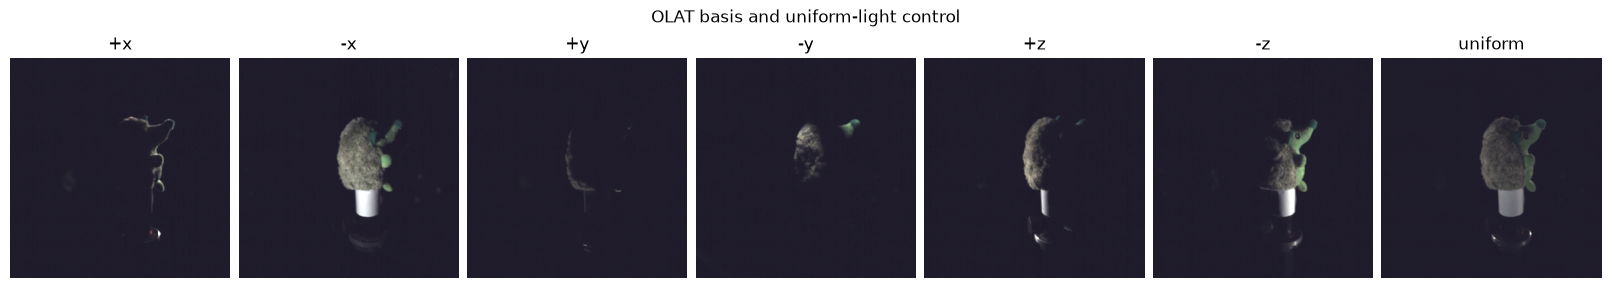

range=[0.0869, 1.0000], clipped channels=0.0658%


In [4]:
preview_weights = torch.cat([torch.eye(6), torch.full((1, 6), 1 / 6)])
preview = dataset.render_weight_batch(
    preview_weights.numpy(), cameras=[CAMERA], light_indices=light_indices.numpy(),
    size=RESOLUTION, center_crop=True, exposure_ev=EXPOSURE_EV, mask=MASK,
    subtract_background=SUBTRACT_BACKGROUND,
)[:, 0]
fig, axes = plt.subplots(1, 7, figsize=(16, 3), constrained_layout=True)
for axis, image, title in zip(axes, preview, (*axis_labels, "uniform")):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")
fig.suptitle("OLAT basis and uniform-light control")
plt.show()
print(f"range=[{preview.min():.4f}, {preview.max():.4f}], clipped channels={100 * (preview >= 1).mean():.4f}%")

## Feature extraction

RayDer produces a backbone camera token $c_i \in \mathbb{R}^{1024}$. Its pose head first applies its learned normalization $N_{pose}$; we retain $z_i^{token}=N_{pose}(c_i)$ before the pose output projection. The nuisance head independently maps the unnormalized token to $z_i^{nuis}=h_{nuis}(c_i) \in \mathbb{R}^{256}$.

For the generic control, the native Transformers DINOv3 ViT-L/16 returns its pooled class token $z_i^{DINO} \in \mathbb{R}^{1024}$. Inputs retain the same $256^2$ crop (a multiple of the 16-pixel patch size) and are normalized with the checkpoint's channel statistics. The public mirror avoids the authorization prompt required by the original release.

In [5]:
from huggingface_hub import hf_hub_download

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp = dict(device_type=device.type, dtype=torch.bfloat16, enabled=device.type == "cuda")
checkpoint = os.environ.get("RAYDER_CHECKPOINT") or hf_hub_download("CompVis/rayder", "rayder_l.pt")
state_dict = torch.load(checkpoint, map_location="cpu", weights_only=True)
if "camera_tokens_2.weight" in state_dict:
    state_dict["nvs_tokens.weight"] = state_dict.pop("camera_tokens_2.weight")
rayder_model = RayDer_L().eval().requires_grad_(False)
rayder_model.load_state_dict(state_dict, strict=True)
rayder_model.to(device)

dino_processor = AutoImageProcessor.from_pretrained(DINO_ID)
dino_model = AutoModel.from_pretrained(DINO_ID).eval().requires_grad_(False).to(device)
dino_mean = torch.tensor(dino_processor.image_mean, device=device)[None, :, None, None]
dino_std = torch.tensor(dino_processor.image_std, device=device)[None, :, None, None]
print(f"device={device}; RayDer token={rayder_model.width}D, nuisance={rayder_model.d_dynamic_state}D; DINO={dino_model.config.hidden_size}D")

Loading weights: 100%|██████████| 415/415 [00:00<00:00, 10963.19it/s]

device=cuda; RayDer token=1024D, nuisance=256D; DINO=1024D


In [6]:
@torch.no_grad()
@torch.compile(dynamic=False, fullgraph=False)
def rayder_features(x):
    B, T, H, W, _ = x.shape
    pos = repeat(make_axial_pos_3d(t=T, h=H, w=W, device=x.device), "(t h w) c -> b t h w c", b=B, t=T, h=H, w=W).clone()
    pos[..., 0] = _prepare_temporal_ranks(B, T, x.device, torch.zeros(T, device=x.device, dtype=torch.long))[:, :, None, None].to(pos)
    tokens = rayder_model.camera_tokens(torch.zeros(B, T, device=x.device, dtype=torch.long))
    registers_pos = einops_reduce(pos, "b t h w c -> b t c", "mean")
    view_type = rayder_model.view_type_embedding(torch.zeros((B, T), device=x.device, dtype=torch.long))
    _, tokens = rayder_model.backbone(
        x=torch.cat([x, x.new_zeros(B, T, H, W, PLUECKER_DIM)], -1), pos=pos, registers=tokens,
        registers_pos=registers_pos, cond_norm=(view_type[:, :, None, None] + rayder_model.token_type_embedding.weight[0]),
        registers_cond_norm=(view_type + rayder_model.token_type_embedding.weight[1]),
    )
    pose_features = rayder_model.camera_pose_head.norm(tokens)
    cameras = Camera.from_parameters(
        rayder_model.camera_pose_head.out_proj(pose_features).double(),
        rayder_model.intrinsics_head(tokens).double(),
    )
    return cameras, pose_features, rayder_model.dynamic_state_head(tokens)

parts = {name: [] for name in ("RayDer token", "RayDer nuisance", "DINOv3")}
rotation_parts, translation_parts, focal_parts = [], [], []
batches = dataset.iter_render_weight_batches(
    mixture_weights.numpy(), cameras=[CAMERA], light_indices=light_indices.numpy(), batch_size=RENDER_BATCH_SIZE,
    size=RESOLUTION, center_crop=True, exposure_ev=EXPOSURE_EV, mask=MASK, subtract_background=SUBTRACT_BACKGROUND,
)
for batch_index, images in enumerate(batches, 1):
    images = torch.from_numpy(images[:, 0]).to(device)
    with torch.autocast(**amp):
        cameras, tokens, nuisance = rayder_features(images[:, None].mul(2).sub(1))
        dino = dino_model(pixel_values=(images.permute(0, 3, 1, 2) - dino_mean) / dino_std).pooler_output
    parts["RayDer token"].append(tokens[:, 0].float().cpu())
    parts["RayDer nuisance"].append(nuisance[:, 0].float().cpu())
    parts["DINOv3"].append(dino.float().cpu())
    rotation_parts.append(cameras.R[:, 0].float().cpu())
    translation_parts.append(cameras.t[:, 0].float().cpu())
    focal_parts.append(cameras.f[:, 0].float().cpu())
    if batch_index == 1 or batch_index % 10 == 0 or batch_index == math.ceil(NUM_MIXTURES / RENDER_BATCH_SIZE):
        print(f"batch {batch_index:3d}/{math.ceil(NUM_MIXTURES / RENDER_BATCH_SIZE)}")

features = {name: torch.cat(value) for name, value in parts.items()}
camera_rotations = torch.cat(rotation_parts)
camera_translations = torch.cat(translation_parts)
camera_focals = torch.cat(focal_parts)
print({name: tuple(value.shape) for name, value in features.items()})

batch   1/63
batch  10/63
batch  20/63
batch  30/63
batch  40/63
batch  50/63
batch  60/63
batch  63/63
{'RayDer token': (500, 1024), 'RayDer nuisance': (500, 256), 'DINOv3': (500, 1024)}


## Reference geometries

Feature distances use standardized Euclidean geometry. For representation $z^r$ with coordinate-wise sample mean $\mu^r$ and standard deviation $\sigma^r$,

$$d_r(i,j)=\left\|\frac{z_i^r-\mu^r}{\sigma^r}-\frac{z_j^r-\mu^r}{\sigma^r}\right\|_2.$$

Two reference distances separate lighting from visible appearance:

1. **Physical illumination:** $d_{illum}(i,j)=W_1(w_i,w_j;C)$, where $C_{kl}=\arccos(\ell_k^\top\ell_l)$ is great-circle transport cost in radians. This respects proximity between light directions.
2. **Image appearance:** with masked, exposure-scaled linear-RGB OLAT vectors $b_k$, $x_i=\sum_k w_{ik}b_k$ and $d_{image}(i,j)=\|x_i-x_j\|_2$. Computing this through the $6\times6$ Gram matrix $G_{kl}=b_k^\top b_l$ is exact and avoids retaining 500 images.

Spearman correlation compares distance rankings. The partial value $\rho(d_r,d_{illum}\mid d_{image})$ residualizes the ranked representation and illumination distances against ranked image distance; it asks whether feature geometry follows physical lighting beyond raw appearance. Pairwise values share samples, so these are descriptive effect sizes rather than independent-observation significance tests.

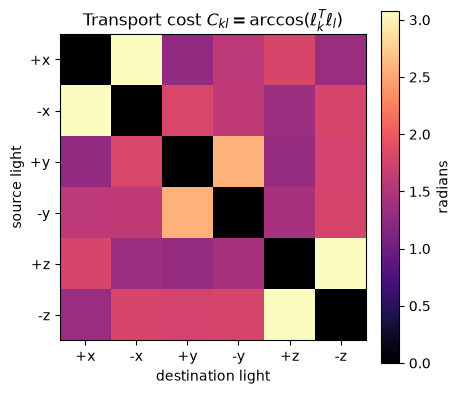

In [7]:
def standardize(x):
    return (x - x.mean(0)) / x.std(0).clamp_min(1e-8)

def spherical_w1(weights, directions, chunk_size=4096):
    cost = torch.acos((directions @ directions.T).clamp(-1, 1))
    cost.fill_diagonal_(0)
    halfspaces = []
    for source in range(len(directions)):
        for target in range(len(directions)):
            if source != target:
                coefficients = torch.zeros(len(directions) - 1)
                if source: coefficients[source - 1] += 1
                if target: coefficients[target - 1] -= 1
                halfspaces.append(torch.cat([coefficients, -cost[source, target, None]]))
    vertices = HalfspaceIntersection(torch.stack(halfspaces).numpy(), np.zeros(len(directions) - 1)).intersections
    vertices = torch.column_stack([torch.zeros(len(vertices)), torch.from_numpy(vertices).float()])
    left, right = torch.triu_indices(len(weights), len(weights), offset=1)
    return torch.cat([
        ((weights[left[start:stop]] - weights[right[start:stop]]) @ vertices.T).amax(1)
        for start in range(0, len(left), chunk_size)
        for stop in [min(start + chunk_size, len(left))]
    ]), cost

basis_srgb = dataset.render_weight_batch(
    torch.eye(6).numpy(), cameras=[CAMERA], light_indices=light_indices.numpy(), size=RESOLUTION,
    center_crop=True, exposure_ev=0, mask=IMAGE_DISTANCE_MASK, subtract_background=SUBTRACT_BACKGROUND,
)[:, 0]
basis_srgb = torch.tensor(basis_srgb)
basis_linear = torch.where(basis_srgb <= 0.04045, basis_srgb / 12.92, ((basis_srgb + 0.055) / 1.055).pow(2.4))
basis_pixels = (basis_linear * 2**EXPOSURE_EV).flatten(1).double()
eigenvalues, eigenvectors = torch.linalg.eigh(basis_pixels @ basis_pixels.T)
image_coordinates = mixture_weights.double() @ (eigenvectors * eigenvalues.clamp_min(0).sqrt())
image_distances = torch.pdist(image_coordinates)
illumination_distances, angular_cost = spherical_w1(mixture_weights, selected_directions)

fig, ax = plt.subplots(figsize=(4.5, 4), constrained_layout=True)
image = ax.imshow(angular_cost, cmap="magma")
ax.set(title=r"Transport cost $C_{kl}=\arccos(\ell_k^T\ell_l)$", xlabel="destination light", ylabel="source light",
       xticks=range(6), yticks=range(6), xticklabels=axis_labels, yticklabels=axis_labels)
fig.colorbar(image, ax=ax, label="radians")
plt.show()

## Parallel measurements

Each representation receives exactly the same measurements:

- $\rho_{illum}=\rho_S(d_r,d_{illum})$: agreement with physical lighting geometry.
- $\rho_{image}=\rho_S(d_r,d_{image})$: agreement with masked pixel appearance.
- $\rho_{illum\mid image}$: physical-lighting agreement after rank-residualizing image distance.
- **held-out $R^2$ / MAE:** a ridge probe predicts the first five mixture weights; $w_6=1-\sum_{k=1}^5w_k$ is implied. One fixed 80/20 split is shared by all representations, and ridge strength is selected only within the training set.

PCA below is descriptive only. It is fit independently to each standardized feature space, and color encodes $e_i$ from the experimental design rather than a fitted label.

representation      rho illum.  rho image rho illum|image   ridge R2  ridge MAE
-------------------------------------------------------------------------------
RayDer token             0.866      0.806        0.598      0.998     0.0059
RayDer nuisance          0.842      0.783        0.555      0.997     0.0071
DINOv3                   0.686      0.624        0.387      0.972     0.0185


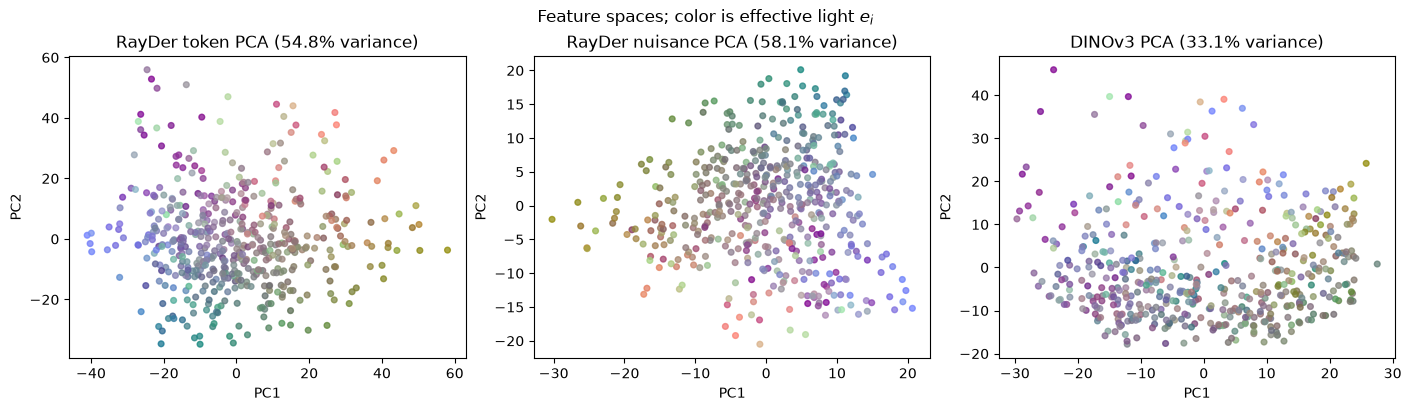

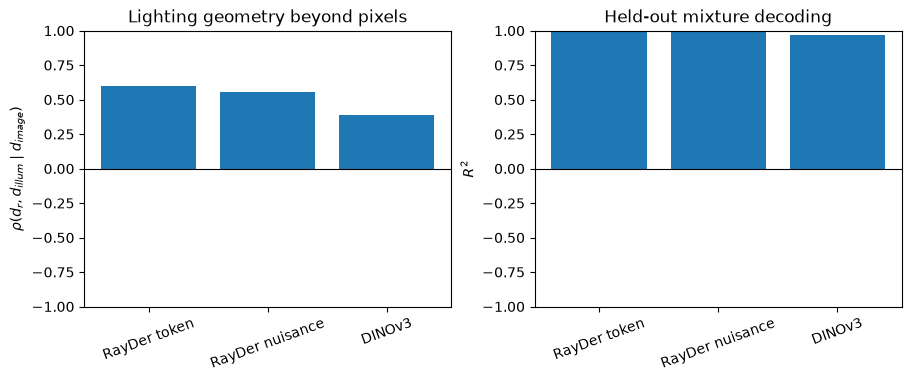

In [11]:
def rho(x, y):
    return float(spearmanr(x.numpy(), y.numpy()).statistic)

def partial_rho(x, y, control):
    ranked = [torch.from_numpy(rankdata(value.numpy())).double() for value in (x, y, control)]
    design = torch.column_stack([torch.ones_like(ranked[2]), ranked[2]])
    residuals = [value - design @ torch.linalg.lstsq(design, value).solution for value in ranked[:2]]
    return torch.corrcoef(torch.stack(residuals))[0, 1].item()

split = torch.randperm(NUM_MIXTURES, generator=torch.Generator().manual_seed(SEED + 1))
train, test = split[: int(0.8 * NUM_MIXTURES)], split[int(0.8 * NUM_MIXTURES):]
target = mixture_weights[:, :5]
metrics, embeddings = {}, {}
for name, values in features.items():
    standardized = standardize(values)
    distances = torch.pdist(standardized)
    _, singular_values, components = torch.linalg.svd(standardized, full_matrices=False)
    embeddings[name] = standardized @ components[:2].T
    probe = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-4, 4, 25)))
    probe.fit(values[train].numpy(), target[train].numpy())
    prediction = probe.predict(values[test].numpy())
    metrics[name] = {
        "rho illumination": rho(distances, illumination_distances),
        "rho image": rho(distances, image_distances),
        "rho illum|image": partial_rho(distances, illumination_distances, image_distances),
        "ridge R2": r2_score(target[test], prediction),
        "ridge MAE": mean_absolute_error(target[test], prediction),
        "PCA variance": (singular_values[:2].square().sum() / singular_values.square().sum()).item(),
    }

header = f"{'representation':<18} {'rho illum.':>11} {'rho image':>10} {'rho illum|image':>12} {'ridge R2':>10} {'ridge MAE':>10}"
print(header)
print("-" * len(header))
for name, values in metrics.items():
    print(f"{name:<18} {values['rho illumination']:>11.3f} {values['rho image']:>10.3f} {values['rho illum|image']:>12.3f} {values['ridge R2']:>10.3f} {values['ridge MAE']:>10.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, (name, embedding) in zip(axes, embeddings.items()):
    ax.scatter(*embedding.T, c=direction_colors, s=17, alpha=0.75)
    ax.set(title=f"{name} PCA ({metrics[name]['PCA variance']:.1%} variance)", xlabel="PC1", ylabel="PC2")
fig.suptitle(r"Feature spaces; color is effective light $e_i$")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.7), constrained_layout=True)
names = list(metrics)
axes[0].bar(names, [metrics[name]["rho illum|image"] for name in names])
axes[0].set(title=r"Lighting geometry beyond pixels", ylabel=r"$\rho(d_r,d_{illum}\mid d_{image})$", ylim=(-1, 1))
axes[1].bar(names, [metrics[name]["ridge R2"] for name in names])
axes[1].set(title="Held-out mixture decoding", ylabel=r"$R^2$", ylim=(-1, 1))
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
    ax.axhline(0, color="black", linewidth=0.8)
plt.show()

## Linear-pixel lighting ceiling

The pixels are analytic exposure-scaled linear OLAT mixtures before display encoding and clipping, matching the image-distance reference rather than the clipped sRGB tensor received by the backbones.

This control asks whether illumination is linearly recoverable from appearance before any learned representation. Let $B\in\mathbb R^{6\times D}$ contain the six flattened, masked linear-RGB OLAT images. Since $x(w)=w^\top B$, the affine ridge probe can be fitted without constructing any $D$-dimensional coefficient matrix:

$$K(w,w')=\frac1D w^\top BB^\top w',\qquad
\hat q_*=\bar q+K_{*,tr}(K_{tr,tr}+\lambda I)^{-1}(q_{tr}-\bar q).$$

Kernel centering, scale normalization, and the fixed numerical ridge $\lambda=10^{-6}$ use training data only. This is an **OLAT image-formation ceiling**: a nearly perfect score is expected by construction and does not imply camera invariance.


In [ ]:
from notebooks.common import dual_ridge_predict, pixel_basis_gram, view_weight_coefficients

pixel_gram = pixel_basis_gram(basis_pixels)
pixel_coefficients = view_weight_coefficients(mixture_weights, 1)[0].double()
train_kernel = pixel_coefficients[train] @ pixel_gram @ pixel_coefficients[train].T
test_train_kernel = pixel_coefficients[test] @ pixel_gram @ pixel_coefficients[train].T
pixel_prediction = dual_ridge_predict(train_kernel, test_train_kernel, target[train])
pixel_r2 = r2_score(target[test].numpy(), pixel_prediction.numpy())
pixel_mae = mean_absolute_error(target[test].numpy(), pixel_prediction.numpy())
print(f"linear pixels: held-out R²={pixel_r2:.6f}, MAE={pixel_mae:.6g}")

names = [*metrics, "linear pixels"]
scores = [*[metrics[name]["ridge R2"] for name in metrics], pixel_r2]
fig, ax = plt.subplots(figsize=(8, 3.8), constrained_layout=True)
ax.bar(names, scores)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="Held-out illumination decoding with pixel ceiling", ylabel=r"$R^2$", ylim=(-1, 1.05))
ax.tick_params(axis="x", rotation=20)
plt.show()


## Pose leakage diagnostic

A fixed camera should ideally give a fixed estimate under changing light. Because a single view has no externally fixed RayDer gauge, these are stability—not pose-accuracy—measurements. Rotation drift is geodesic distance to the mean predicted rotation; translation drift is Euclidean distance to the median translation; focal drift is relative to the median focal length.

In [9]:
rotations = Rotation.from_matrix(camera_rotations.numpy())
rotation_drift = torch.from_numpy(np.rad2deg((rotations.mean().inv() * rotations).magnitude()))
translation_drift = torch.linalg.vector_norm(camera_translations - camera_translations.median(0).values, dim=1)
median_focal = camera_focals.median()
focal_drift = 100 * (camera_focals - median_focal).abs() / median_focal
for name, values, unit in [
    ("rotation", rotation_drift, "deg"),
    ("translation", translation_drift, ""),
    ("focal", focal_drift, "%"),
]:
    print(f"{name:<12} median={values.median():.6f}{unit:<3} p95={values.quantile(0.95):.6f}{unit}")

rotation     median=1.950645deg p95=4.709787deg
translation  median=0.170682    p95=0.556901
focal        median=0.195119%   p95=0.587664%
